# Phân Khúc Ảnh Bằng Thuật Toán K-Means (Image Segmentation)

Notebook này triển khai phân khúc ảnh theo đúng các bước yêu cầu trong [implement.md](file:///C:/Users/Win%2011/Documents/ML/ML_proj_26/lab3/additional/implement.md) và phân tích các dạng phân khúc ảnh trên 3 không gian màu chính: **RGB**, **HSV** và **LAB** sử dụng thư viện **OpenCV**.

## Phần A. Thảo Luận: 4 Loại Phân Khúc Ảnh (Types of Image Segmentation)

Trong thị giác máy tính, có 4 dạng phân khúc ảnh chính bao gồm:

1. **Phân khúc ngữ nghĩa (Semantic Segmentation)**:
   - **Định nghĩa**: Gán nhãn lớp đối tượng (ví dụ: người, xe, đường, bầu trời) cho từng pixel.
   - **Đặc điểm**: Không phân biệt giữa các thực thể khác nhau trong cùng một lớp (ví dụ: 3 chiếc xe ô tô đều được tô cùng một màu đặc trưng đại diện cho lớp "xe").
2. **Phân khúc cá thể / thực thể (Instance Segmentation)**:
   - **Định nghĩa**: Xác định và phân lớp đối tượng đồng thời phân biệt rõ rệt từng thực thể đơn lẻ.
   - **Đặc điểm**: Nếu trong ảnh có 3 chiếc xe ô tô, chúng sẽ được tô bằng 3 màu khác nhau để ký hiệu "xe 1", "xe 2", và "xe 3".
3. **Phân khúc toàn cảnh (Panoptic Segmentation)**:
   - **Định nghĩa**: Sự kết hợp hoàn hảo giữa phân khúc ngữ nghĩa và phân khúc thực thể.
   - **Đặc điểm**: Phân loại toàn bộ các pixel trong ảnh. Các đối tượng đếm được (người, xe) được tách biệt theo thực thể (Instance), còn các vùng nền (bầu trời, đường, cỏ) được phân loại theo ngữ nghĩa (Semantic).
4. **Phân khúc dựa trên thuộc tính vật lý/màu sắc (Color/Clustering-based Segmentation)**:
   - **Định nghĩa**: Nhóm các điểm ảnh dựa trên sự tương đồng về giá trị màu sắc (Feature vectors) bằng thuật toán gom cụm (K-Means, DBSCAN).
   - **Đặc điểm**: Không có thông tin ngữ nghĩa (Non-semantic). Máy tính chỉ nhóm các điểm ảnh có sắc độ màu gần nhau trên không gian vector mà không hiểu đó là vật thể gì. Đây chính là phương pháp chúng ta cài đặt dưới đây.

## Phần B. Thảo Luận: Lựa Chọn Ảnh Phù Hợp Cho K-Means

- **Ảnh nên dùng**: Ảnh có các khối màu tách biệt rõ ràng, độ tương phản cao, ít dải màu chuyển mịn (như logo, tranh hoạt hình, đồ vật đơn sắc trên nền phẳng).
- **Ảnh không nên dùng**: Ảnh có dải màu chuyển mịn (Gradients) như hoàng hôn, bầu trời xanh trong, hoặc ảnh có bề mặt họa tiết quá phức tạp (nhiễu điểm ảnh lớn). K-Means sẽ chia dải mịn thành các khối màu sắc cạnh (gây lỗi vỡ màu/color banding).

## Phần C. Cài Đặt Thư Viện Và Định Nghĩa Lớp KMeansScratch

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import pandas as pd

sns.set_theme(style="white")

class KMeansScratch:
    def __init__(self, n_clusters=3, max_iters=50, init='random', metric='euclidean', tol=1e-4, random_state=42):
        self.n_clusters = n_clusters
        self.max_iters = max_iters
        self.init = init
        self.metric = metric
        self.tol = tol
        self.random_state = random_state
        self.centroids = None
        self.labels_ = None
        self.inertia_ = None
        self.n_iter_ = 0
        self.history_ = []
        
    def _compute_distances(self, X):
        if self.metric == 'euclidean':
            X_squared = np.sum(X**2, axis=1, keepdims=True)
            return X_squared - 2 * np.dot(X, self.centroids.T) + np.sum(self.centroids**2, axis=1)
        elif self.metric == 'manhattan':
            return np.sum(np.abs(X[:, np.newaxis] - self.centroids), axis=2)
            
    def _compute_inertia(self, X, labels):
        return np.sum((X - self.centroids[labels]) ** 2)
        
    def fit(self, X):
        np.random.seed(self.random_state)
        n_samples, n_features = X.shape
        self.history_ = []
        
        # 1. Khởi tạo tâm cụm
        if self.init == 'random':
            random_idx = np.random.choice(n_samples, self.n_clusters, replace=False)
            self.centroids = X[random_idx].copy().astype(float)
        elif self.init == 'kmeans++':
            centroids = [X[np.random.choice(n_samples)]]
            for _ in range(1, self.n_clusters):
                dists_min = np.min([np.sum((X - c)**2, axis=1) for c in centroids], axis=0)
                probs = dists_min / (dists_min.sum() + 1e-10)
                next_c_idx = np.random.choice(n_samples, p=probs)
                centroids.append(X[next_c_idx])
            self.centroids = np.array(centroids).astype(float)
            
        # 2. Vòng lặp tối ưu
        for i in range(self.max_iters):
            self.n_iter_ = i + 1
            distances = self._compute_distances(X)
            labels = np.argmin(distances, axis=1)
            
            new_centroids = []
            for k in range(self.n_clusters):
                cluster_pts = X[labels == k]
                if len(cluster_pts) > 0:
                    if self.metric == 'manhattan':
                        new_centroids.append(np.median(cluster_pts, axis=0))
                    else:
                        new_centroids.append(cluster_pts.mean(axis=0))    
                else:
                    new_centroids.append(self.centroids[k])
            new_centroids = np.array(new_centroids)
            
            centroid_shift = np.linalg.norm(new_centroids - self.centroids)
            self.centroids = new_centroids
            
            # Tính lại nhãn và inertia theo tâm mới
            distances_after_update = self._compute_distances(X)
            labels_after_update = np.argmin(distances_after_update, axis=1)
            inertia = self._compute_inertia(X, labels_after_update)
            cluster_sizes = [int(np.sum(labels_after_update == k)) for k in range(self.n_clusters)]
            
            self.history_.append({
                "iteration": i + 1,
                "inertia": inertia,
                "centroid_shift": centroid_shift,
                "cluster_sizes": cluster_sizes,
                "centroids": self.centroids.copy()
            })
            
            if centroid_shift < self.tol:
                break
            
        final_distances = self._compute_distances(X)
        self.labels_ = np.argmin(final_distances, axis=1)
        self.inertia_ = self._compute_inertia(X, self.labels_)
        return self
        
    def display_history(self, show_centroids=False):
        if len(self.history_) == 0:
            print("Model chưa được train hoặc history_ đang rỗng.")
            return None
        rows = []
        for h in self.history_:
            row = {
                "iteration": h["iteration"],
                "inertia": h["inertia"],
                "centroid_shift": h["centroid_shift"],
                "cluster_sizes": h["cluster_sizes"]
            }
            if show_centroids:
                row["centroids"] = h["centroids"]
            rows.append(row)
        return pd.DataFrame(rows)

## Task 1: Load the Image (Đọc và hiển thị ảnh)

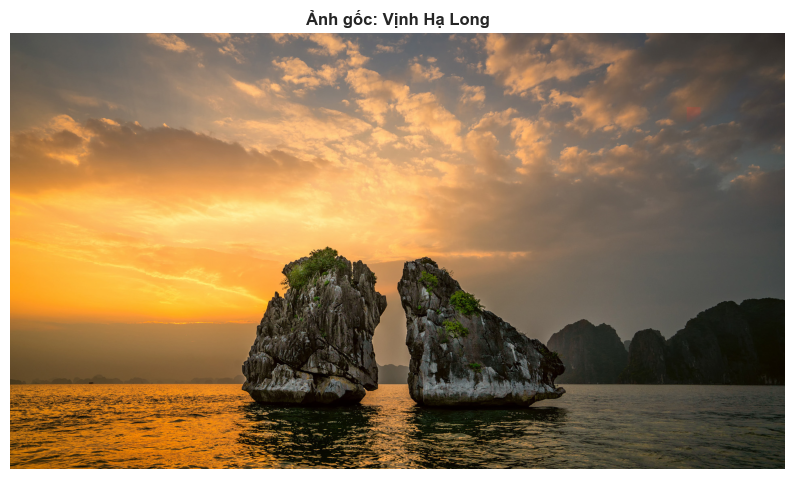

In [2]:
# Load ảnh gốc bằng OpenCV (đọc dạng BGR rồi chuyển đổi sang RGB để vẽ)
img_bgr = cv2.imread('image.png')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Hiển thị ảnh gốc
plt.figure(figsize=(10, 6))
plt.imshow(img_rgb)
plt.title("Ảnh gốc: Vịnh Hạ Long", fontsize=12, fontweight='bold')
plt.axis('off')
plt.show()

## Task 2: Preprocess the Image (Resize & Flatten)

In [3]:
# Resize ảnh về chiều rộng 400px (đảm bảo độ sắc nét cao, không bị vỡ ảnh pixel thô)
height, width, _ = img_rgb.shape
new_width = 400
new_height = int(height * (new_width / width))
img_resized = cv2.resize(img_rgb, (new_width, new_height))

# 1. Chuẩn hóa dữ liệu về dải [0, 1] và phẳng hóa (Flatten) thành mảng 2D cho RGB
pixels_rgb = (img_resized / 255.0).reshape(-1, 3).astype(float)

# 2. Chuyển đổi sang không gian HSV và phẳng hóa bằng OpenCV
img_hsv = cv2.cvtColor(img_resized, cv2.COLOR_RGB2HSV)
# Chuẩn hóa giá trị HSV về [0, 1] để huấn luyện K-Means đồng bộ
pixels_hsv = (img_hsv / np.array([179.0, 255.0, 255.0])).reshape(-1, 3).astype(float)

# 3. Chuyển đổi sang không gian LAB và phẳng hóa bằng OpenCV
img_lab = cv2.cvtColor(img_resized, cv2.COLOR_RGB2LAB)
# Chuẩn hóa giá trị LAB về [0, 1] để huấn luyện K-Means đồng bộ
pixels_lab = (img_lab / np.array([255.0, 255.0, 255.0])).reshape(-1, 3).astype(float)

print(f"Ảnh gốc: {width}x{height} -> Ảnh sau khi resize: {new_width}x{new_height}")
print(f"Mảng phẳng hóa RGB có kích thước: {pixels_rgb.shape}")

Ảnh gốc: 1920x1080 -> Ảnh sau khi resize: 400x225
Mảng phẳng hóa RGB có kích thước: (90000, 3)


## Task 3: Apply K-Means Clustering (Khảo sát đồ thị Elbow & Huấn luyện)

Khảo sát chất lượng phân cụm từ K=1 đến K=8:
K = 1 | Inertia = 13201.4708 | Silhouette Score = N/A


K = 2 | Inertia = 4982.3709 | Silhouette Score (Mẫu) = 0.5163


K = 3 | Inertia = 2560.3675 | Silhouette Score (Mẫu) = 0.5102


K = 4 | Inertia = 1794.9966 | Silhouette Score (Mẫu) = 0.4616


K = 5 | Inertia = 1416.9737 | Silhouette Score (Mẫu) = 0.4666


K = 6 | Inertia = 1113.6783 | Silhouette Score (Mẫu) = 0.4583


K = 7 | Inertia = 967.9242 | Silhouette Score (Mẫu) = 0.4403


K = 8 | Inertia = 830.8235 | Silhouette Score (Mẫu) = 0.4400


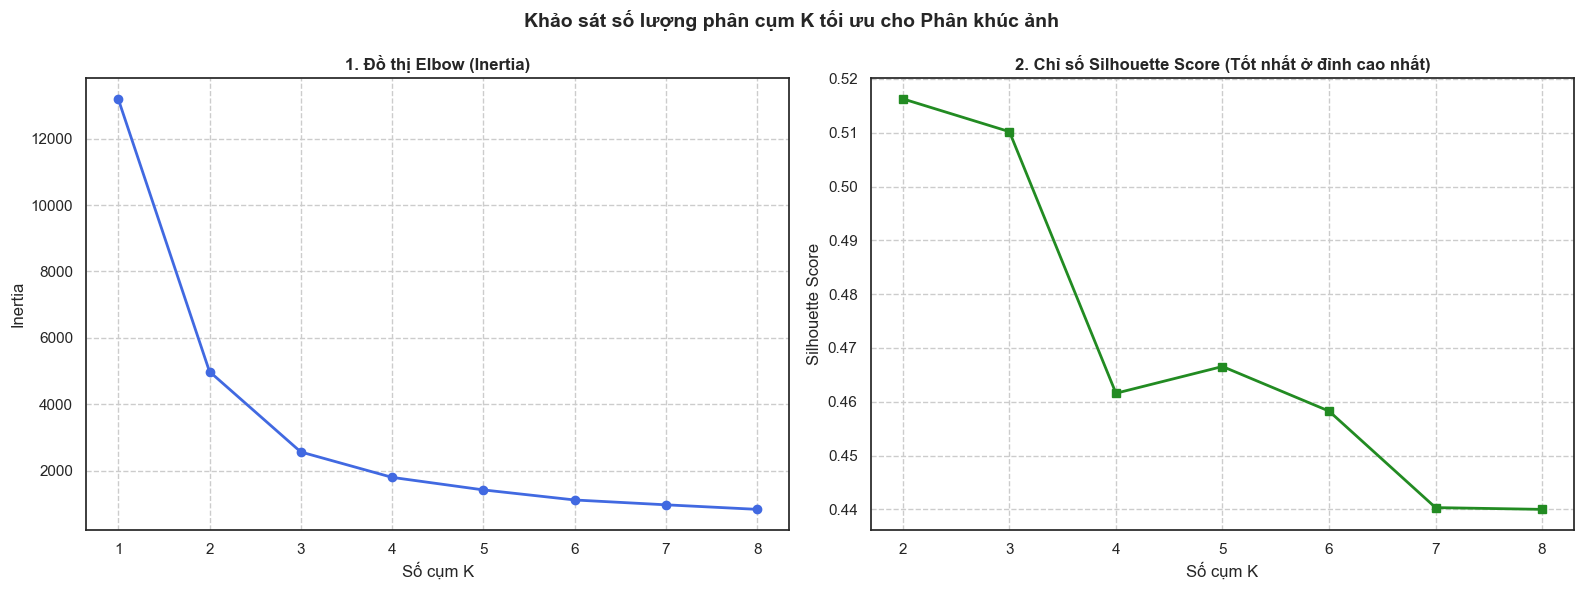

In [4]:
# Chạy khảo sát Elbow và Silhouette từ K=1 đến K=8 trên không gian màu RGB
from sklearn.metrics import silhouette_score

inertia_list = []
silhouette_list = []
k_range = range(1, 9)

# Để tránh lỗi tràn bộ nhớ (OOM) và chạy siêu chậm khi tính Silhouette trên 90,000 pixels,
# ta sử dụng phương pháp lấy mẫu ngẫu nhiên (subsampling) 2,000 pixels đại diện.
np.random.seed(42)
sample_idx = np.random.choice(len(pixels_rgb), size=2000, replace=False)
pixels_sample = pixels_rgb[sample_idx]

print("Khảo sát chất lượng phân cụm từ K=1 đến K=8:")
for k in k_range:
    km = KMeansScratch(n_clusters=k, max_iters=20, init='random', random_state=42).fit(pixels_rgb)
    inertia_list.append(km.inertia_)
    
    if k >= 2:
        # Tính nhãn cho các điểm dữ liệu trong tập mẫu
        sample_dists = km._compute_distances(pixels_sample)
        sample_labels = np.argmin(sample_dists, axis=1)
        score = silhouette_score(pixels_sample, sample_labels)
        silhouette_list.append(score)
        print(f"K = {k} | Inertia = {km.inertia_:.4f} | Silhouette Score (Mẫu) = {score:.4f}")
    else:
        print(f"K = {k} | Inertia = {km.inertia_:.4f} | Silhouette Score = N/A")

# Vẽ 2 biểu đồ so sánh side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Biểu đồ Elbow (Inertia)
axes[0].plot(list(k_range), inertia_list, marker='o', color='royalblue', linewidth=2)
axes[0].set_title("1. Đồ thị Elbow (Inertia)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Số cụm K")
axes[0].set_ylabel("Inertia")
axes[0].set_xticks(list(k_range))
axes[0].grid(True, linestyle='--')

# 2. Biểu đồ Silhouette Score
axes[1].plot(list(range(2, 9)), silhouette_list, marker='s', color='forestgreen', linewidth=2)
axes[1].set_title("2. Chỉ số Silhouette Score (Tốt nhất ở đỉnh cao nhất)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Số cụm K")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_xticks(list(range(2, 9)))
axes[1].grid(True, linestyle='--')

plt.suptitle("Khảo sát số lượng phân cụm K tối ưu cho Phân khúc ảnh", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Task 4: Segment the Image (Tạo ảnh phân khúc)

In [5]:
# Chọn K = 3 dựa trên đồ thị Elbow để phân tách đá, trời và nước
K = 3

# Phân khúc trên không gian màu RGB
km_rgb = KMeansScratch(n_clusters=K, max_iters=30, init='random', random_state=42).fit(pixels_rgb)
segmented_rgb = km_rgb.centroids[km_rgb.labels_]
img_seg_rgb = (segmented_rgb.reshape(img_resized.shape) * 255).astype(np.uint8)

# Phân khúc trên không gian màu HSV
km_hsv = KMeansScratch(n_clusters=K, max_iters=30, init='random', random_state=42).fit(pixels_hsv)
segmented_hsv = km_hsv.centroids[km_hsv.labels_] * np.array([179.0, 255.0, 255.0])
img_seg_hsv = cv2.cvtColor(segmented_hsv.reshape(img_resized.shape).astype(np.uint8), cv2.COLOR_HSV2RGB)

# Phân khúc trên không gian màu LAB
km_lab = KMeansScratch(n_clusters=K, max_iters=30, init='random', random_state=42).fit(pixels_lab)
segmented_lab = km_lab.centroids[km_lab.labels_] * np.array([255.0, 255.0, 255.0])
img_seg_lab = cv2.cvtColor(segmented_lab.reshape(img_resized.shape).astype(np.uint8), cv2.COLOR_LAB2RGB)

## Task 5: Visualize the Results (Vẽ biểu đồ so sánh side-by-side)

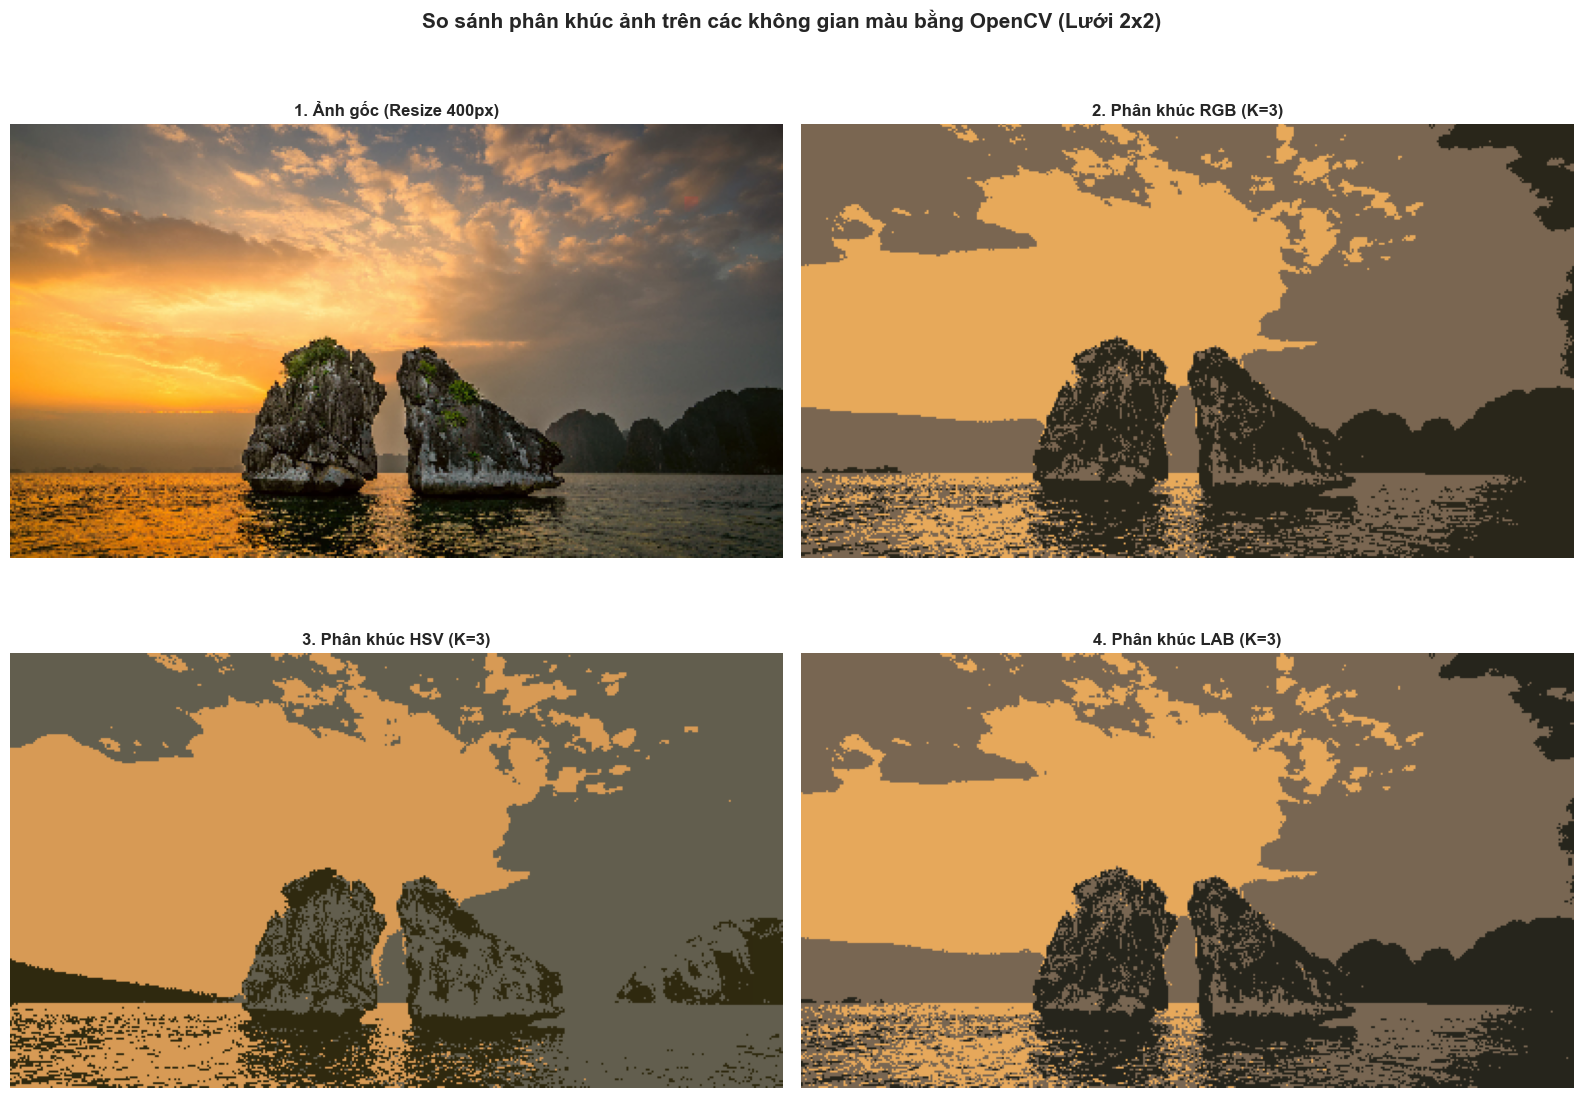

In [6]:
# Vẽ ảnh gốc và ảnh sau khi phân khúc (RGB, HSV, LAB) dưới dạng lưới 2x2
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes[0, 0].imshow(img_resized)
axes[0, 0].set_title("1. Ảnh gốc (Resize 400px)", fontsize=12, fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(img_seg_rgb)
axes[0, 1].set_title(f"2. Phân khúc RGB (K={K})", fontsize=12, fontweight='bold')
axes[0, 1].axis('off')

axes[1, 0].imshow(img_seg_hsv)
axes[1, 0].set_title(f"3. Phân khúc HSV (K={K})", fontsize=12, fontweight='bold')
axes[1, 0].axis('off')

axes[1, 1].imshow(img_seg_lab)
axes[1, 1].set_title(f"4. Phân khúc LAB (K={K})", fontsize=12, fontweight='bold')
axes[1, 1].axis('off')

plt.suptitle("So sánh phân khúc ảnh trên các không gian màu bằng OpenCV (Lưới 2x2)", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## Task 6: Practical Demo of the 4 Segmentation Types (Lập trình minh họa 4 loại phân khúc ảnh)

Để hiểu rõ sự khác biệt giữa 4 loại phân khúc ảnh (Color-based, Semantic, Instance, Panoptic), chúng ta sử dụng kết quả K-Means (K=3) ở trên kết hợp với giới hạn vùng tọa độ quan tâm (Region of Interest - ROI) để bóc tách chính xác hai đảo đá ở giữa, loại bỏ hoàn toàn các bóng phản chiếu và dãy núi phía xa ở rìa ảnh:
1. **Color-based Segmentation**: Phân cụm màu thô của K-Means.
2. **Semantic Segmentation**: Gán màu lớp ngữ nghĩa: Bầu trời (Xanh nhạt), Nước biển (Xanh đậm), Đảo đá (Màu xám).
3. **Instance Segmentation**: Tách biệt 2 đảo đá độc lập ở giữa (Đá trái: Đỏ, Đá phải: Xanh lá). Các phần bóng nước và núi xa rìa bị loại bỏ.
4. **Panoptic Segmentation**: Kết hợp cả nền của Semantic và hòn đá của Instance.

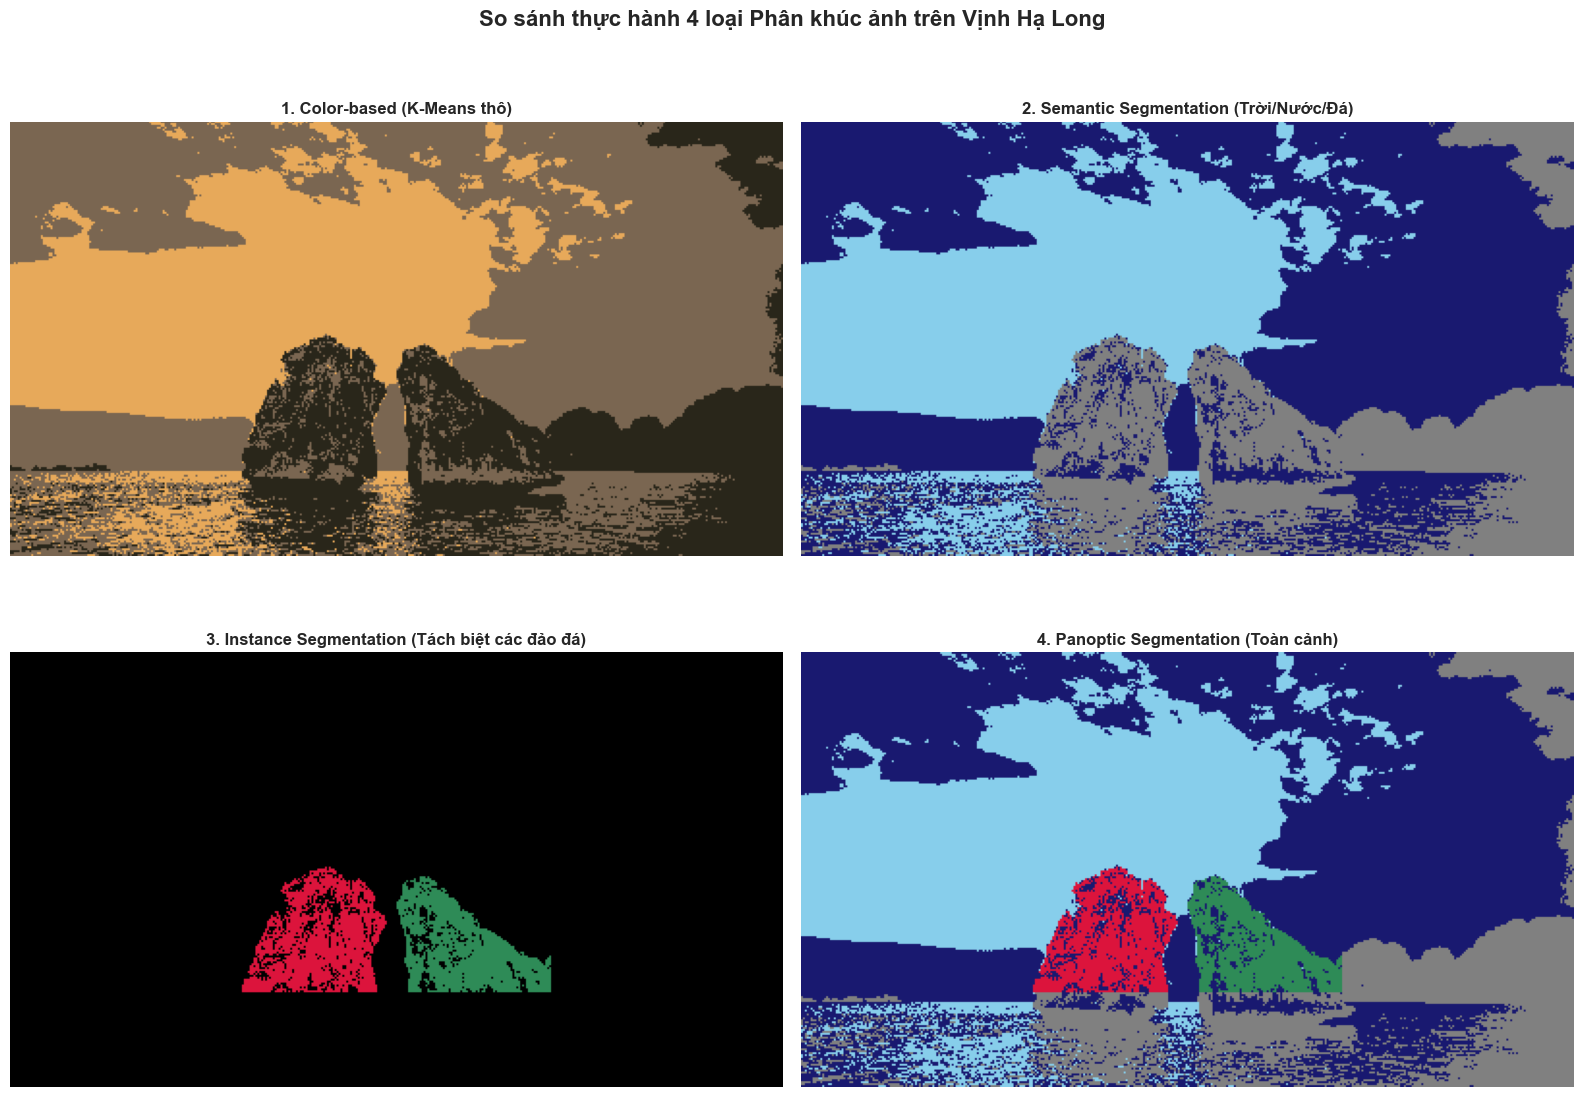

In [7]:
# 1. Phân tích ngữ nghĩa từ kết quả K-Means
# Tìm nhãn của đá, nước, trời dựa trên độ sáng (tổng RGB)
centroid_brightness = np.sum(km_rgb.centroids, axis=1)
sorted_indices = np.argsort(centroid_brightness)
rock_label = sorted_indices[0]
water_label = sorted_indices[1]
sky_label = sorted_indices[2]

# Tạo nhãn mặt nạ 2D
labels_2d = km_rgb.labels_.reshape(img_resized.shape[:2])

# A. Color-based (K-Means thô)
img_color_based = img_seg_rgb.copy()

# B. Semantic Segmentation (Gán màu lớp)
img_semantic = np.zeros_like(img_resized)
img_semantic[labels_2d == sky_label] = [135, 206, 235]   # Bầu trời: Xanh nhạt (Sky Blue)
img_semantic[labels_2d == water_label] = [25, 25, 112]   # Mặt nước: Xanh hải quân (Midnight Blue)
img_semantic[labels_2d == rock_label] = [128, 128, 128]  # Đảo đá: Xám (Grey)

# C. Instance Segmentation (Tách biệt các đảo đá độc lập bằng ROI)
h, w = labels_2d.shape
Y_grid, X_grid = np.ogrid[:h, :w]

# Bóc tách hòn đá trái (x khoảng 115 đến 195, y khoảng 90 đến 176)
left_rock_mask = (labels_2d == rock_label) & (X_grid >= 115) & (X_grid < 195) & (Y_grid >= 90) & (Y_grid < 176)
# Bóc tách hòn đá phải (x khoảng 195 đến 280, y khoảng 90 đến 176)
right_rock_mask = (labels_2d == rock_label) & (X_grid >= 195) & (X_grid < 280) & (Y_grid >= 90) & (Y_grid < 176)

img_instance = np.zeros_like(img_resized)
img_instance[left_rock_mask] = [220, 20, 60]      # Hòn đá trái: Đỏ (Crimson)
img_instance[right_rock_mask] = [46, 139, 87]     # Hòn đá phải: Xanh lá (SeaGreen)

# D. Panoptic Segmentation (Gộp nền ngữ nghĩa + thực thể hòn đá)
img_panoptic = img_semantic.copy()
img_panoptic[left_rock_mask] = [220, 20, 60]
img_panoptic[right_rock_mask] = [46, 139, 87]

# Trực quan hóa so sánh 4 loại phân khúc ảnh
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes[0, 0].imshow(img_color_based)
axes[0, 0].set_title("1. Color-based (K-Means thô)", fontsize=12, fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(img_semantic)
axes[0, 1].set_title("2. Semantic Segmentation (Trời/Nước/Đá)", fontsize=12, fontweight='bold')
axes[0, 1].axis('off')

axes[1, 0].imshow(img_instance)
axes[1, 0].set_title("3. Instance Segmentation (Tách biệt các đảo đá)", fontsize=12, fontweight='bold')
axes[1, 0].axis('off')

axes[1, 1].imshow(img_panoptic)
axes[1, 1].set_title("4. Panoptic Segmentation (Toàn cảnh)", fontsize=12, fontweight='bold')
axes[1, 1].axis('off')

plt.suptitle("So sánh thực hành 4 loại Phân khúc ảnh trên Vịnh Hạ Long", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()